In [ ]:
%pip install -q pymssql pandas numpy scikit-learn matplotlib seaborn statsmodels python-dotenv

## Setup

This notebook connects to the Azure SQL database. Create a `.env` file in this directory (`MachineLearning/ml-pipelines/.env`) with:

```
DB_SERVER=lunas-project-intex-sql.database.windows.net
DB_DATABASE=lunas-project-db
DB_USERNAME=sqladmin
DB_PASSWORD=<your-password>
```

# Safehouse Performance Analyzer

Compute a composite performance score for each safehouse to help leadership identify facilities that need attention or can share best practices.

## 1. Problem Framing

**Business Problem:** Lighthouse Philippines operates 9 safehouses. Leadership needs an objective way to compare safehouse performance across multiple dimensions — education, health, safety, and service delivery.

**Approach:** Weighted composite scoring across 4 normalized dimensions:
- Education progress (25%)
- Health outcomes (25%)
- Safety / inverse incidents (25%)
- Service delivery volume (25%)

**Output:** Performance score (0-1) and label (HighPerforming / Average / NeedsAttention) per safehouse.

This is a **descriptive/ranking** pipeline, not a predictive model. It synthesizes existing metrics into an actionable summary.

## 2. Data Preparation

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymssql
import re as _re

sns.set_style('whitegrid')

# ── Azure SQL connection ─────────────────────────────────────────────────────
from dotenv import load_dotenv
import os
load_dotenv()

SERVER = os.getenv('DB_SERVER')
DATABASE = os.getenv('DB_DATABASE')
USER = os.getenv('DB_USERNAME')
PASSWORD = os.getenv('DB_PASSWORD')

conn = pymssql.connect(server=SERVER, user=USER, password=PASSWORD,
                       database=DATABASE, port=1433, tds_version='7.3')

def load_table(table_name):
    df = pd.read_sql(f'SELECT * FROM {table_name}', conn)
    df.columns = [_re.sub(r'(?<!^)(?=[A-Z])', '_', c).lower() for c in df.columns]
    return df

# ── Load data ────────────────────────────────────────────────────────────────
metrics = load_table('SafehouseMonthlyMetrics')
incidents = load_table('IncidentReports')
safehouses = load_table('Safehouses')

print(f'SafehouseMonthlyMetrics: {metrics.shape}')
print(f'IncidentReports:         {incidents.shape}')
print(f'Safehouses:              {safehouses.shape}')
print(f'\nSafehouses: {safehouses["name"].tolist()}')

SafehouseMonthlyMetrics: (450, 11)
IncidentReports:         (100, 12)
Safehouses:              (9, 13)

Safehouses: ['Lighthouse Safehouse 1', 'Lighthouse Safehouse 2', 'Lighthouse Safehouse 3', 'Lighthouse Safehouse 4', 'Lighthouse Safehouse 5', 'Lighthouse Safehouse 6', 'Lighthouse Safehouse 7', 'Lighthouse Safehouse 8', 'Lighthouse Safehouse 9']


In [2]:
# ── Aggregate metrics per safehouse ──────────────────────────────────────────
sh_agg = metrics.groupby('safehouse_id').agg(
    avg_education=('avg_education_progress', 'mean'),
    avg_health=('avg_health_score', 'mean'),
    total_visits=('home_visitation_count', 'sum'),
    total_recordings=('process_recording_count', 'sum'),
    total_incidents=('incident_count', 'sum'),
    avg_residents=('active_residents', 'mean'),
    months_reported=('metric_id', 'count')
).reset_index()

# Incident severity weighting
severity_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
incidents['severity_weight'] = incidents['severity'].map(severity_map).fillna(2)
inc_agg = incidents.groupby('safehouse_id').agg(
    weighted_incidents=('severity_weight', 'sum'),
    unresolved=('resolved', lambda x: (~x.astype(bool)).sum())
).reset_index()

df = sh_agg.merge(safehouses[['safehouse_id', 'name', 'region', 'capacity_girls', 'current_occupancy']],
                   on='safehouse_id', how='left')
df = df.merge(inc_agg, on='safehouse_id', how='left')
df['weighted_incidents'] = df['weighted_incidents'].fillna(0)
df['unresolved'] = df['unresolved'].fillna(0)

# Service delivery score (visits + recordings per resident)
df['service_per_resident'] = (df['total_visits'] + df['total_recordings']) / df['avg_residents'].clip(lower=1)

print(df[['safehouse_id', 'name', 'avg_education', 'avg_health', 'weighted_incidents', 'service_per_resident']].to_string(index=False))

 safehouse_id                   name  avg_education  avg_health  weighted_incidents  service_per_resident
            1 Lighthouse Safehouse 1      78.005000    3.262222                  42             77.200000
            2 Lighthouse Safehouse 2      78.071724    3.206897                  15             49.625000
            3 Lighthouse Safehouse 3      84.035000    3.391786                  22             68.000000
            4 Lighthouse Safehouse 4      72.312759    3.234483                  33             82.000000
            5 Lighthouse Safehouse 5      84.339200    3.208000                  21             89.000000
            6 Lighthouse Safehouse 6      84.997333    3.209667                  14             65.200000
            7 Lighthouse Safehouse 7      68.283333    3.036000                  28             57.000000
            8 Lighthouse Safehouse 8      83.380968    3.200323                   8             63.333333
            9 Lighthouse Safehouse 9      65.6

## 3. Composite Scoring

In [3]:
# ── Normalize each dimension to 0-1 ──────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

dims = ['avg_education', 'avg_health', 'service_per_resident']
scaler = MinMaxScaler()
df[['norm_education', 'norm_health', 'norm_service']] = scaler.fit_transform(df[dims])

# Inverse incidents (lower = better)
max_inc = df['weighted_incidents'].max()
df['norm_safety'] = 1 - (df['weighted_incidents'] / max_inc) if max_inc > 0 else 1

# ── Weighted composite ──────────────────────────────────────────────────────
WEIGHTS = {'education': 0.25, 'health': 0.25, 'safety': 0.25, 'service': 0.25}

df['composite_score'] = (
    WEIGHTS['education'] * df['norm_education'] +
    WEIGHTS['health'] * df['norm_health'] +
    WEIGHTS['safety'] * df['norm_safety'] +
    WEIGHTS['service'] * df['norm_service']
).round(4)

df['label'] = pd.cut(df['composite_score'], bins=[0, 0.4, 0.7, 1.01],
                      labels=['NeedsAttention', 'Average', 'HighPerforming'])
df = df.sort_values('composite_score', ascending=False)

print('Safehouse Performance Rankings:')
print(df[['name', 'region', 'composite_score', 'label', 'norm_education',
           'norm_health', 'norm_safety', 'norm_service']].to_string(index=False))

Safehouse Performance Rankings:
                  name   region  composite_score          label  norm_education  norm_health  norm_safety  norm_service
Lighthouse Safehouse 5    Luzon           0.8072 HighPerforming        0.965948     0.762689     0.500000      1.000000
Lighthouse Safehouse 3 Mindanao           0.7233 HighPerforming        0.950209     1.000000     0.476190      0.466667
Lighthouse Safehouse 6 Mindanao           0.7068 HighPerforming        1.000000     0.764842     0.666667      0.395556
Lighthouse Safehouse 8  Visayas           0.7067 HighPerforming        0.916369     0.752776     0.809524      0.348148
Lighthouse Safehouse 4  Visayas           0.5443        Average        0.343698     0.796885     0.214286      0.822222
Lighthouse Safehouse 1    Luzon           0.5428        Average        0.638215     0.832703     0.000000      0.700317
Lighthouse Safehouse 2  Visayas           0.5114        Average        0.641668     0.761265     0.642857      0.000000
Lighthou

## 4. Visualization

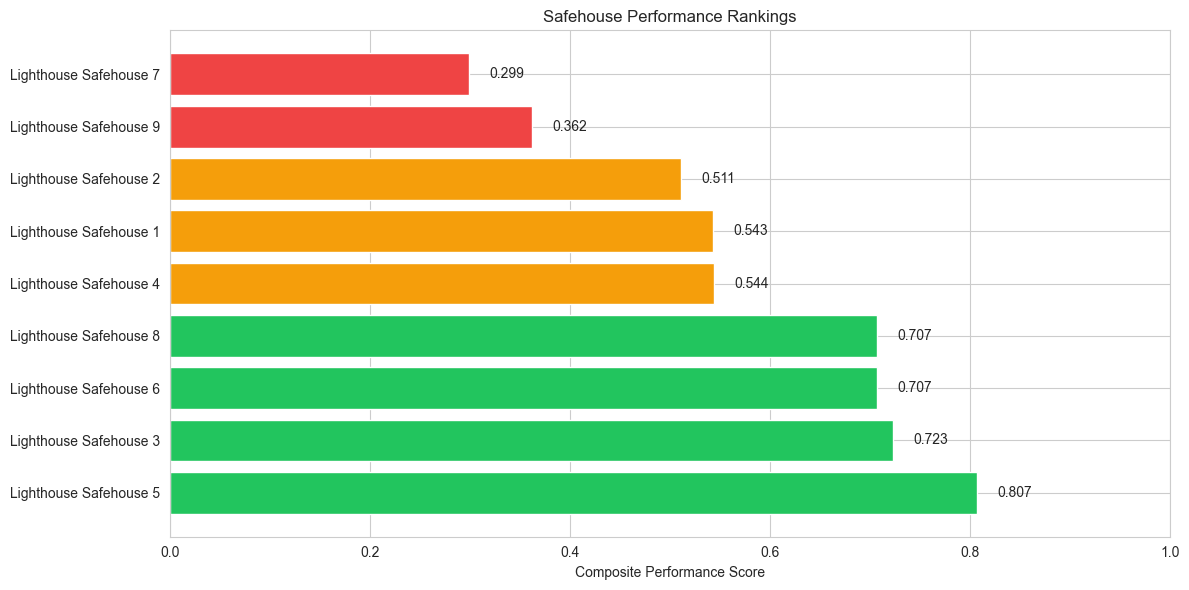

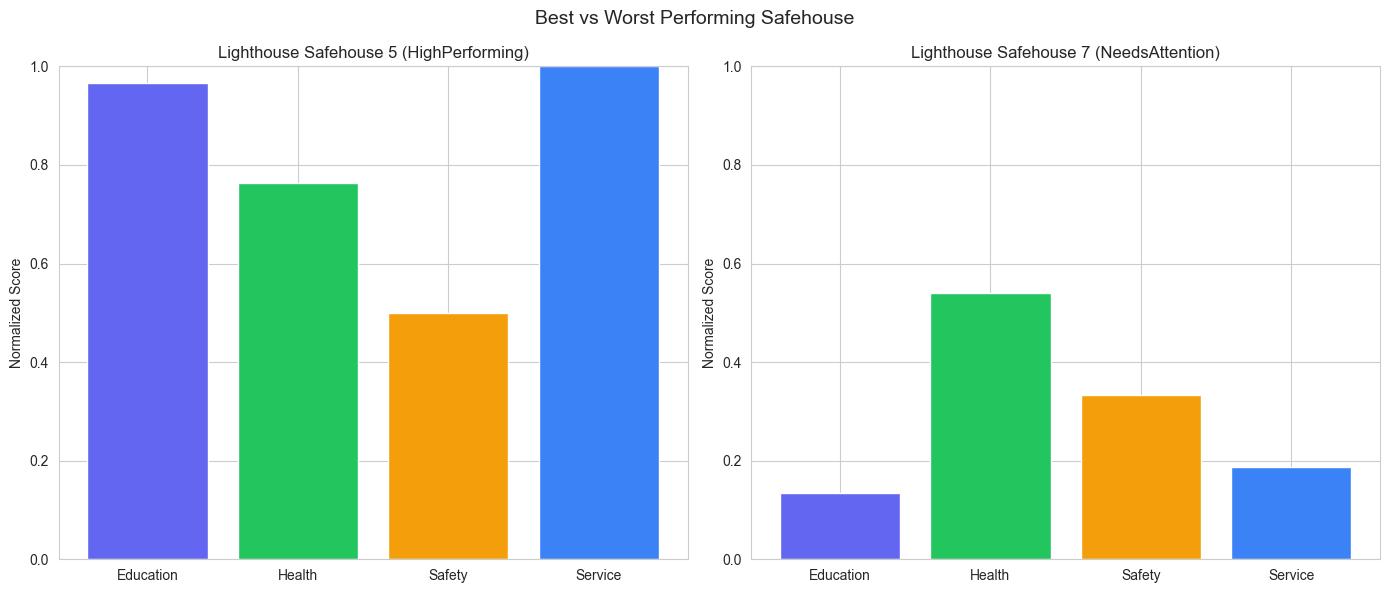

In [4]:
# ── Bar chart ────────────────────────────────────────────────────────────────
colors = {'HighPerforming': '#22c55e', 'Average': '#f59e0b', 'NeedsAttention': '#ef4444'}
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df['name'], df['composite_score'],
               color=[colors.get(str(l), '#888') for l in df['label']])
ax.set_xlabel('Composite Performance Score')
ax.set_title('Safehouse Performance Rankings')
ax.set_xlim(0, 1)
for bar, score in zip(bars, df['composite_score']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center')
plt.tight_layout()
plt.show()

# ── Radar chart for top and bottom ──────────────────────────────────────────
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
dims_plot = ['norm_education', 'norm_health', 'norm_safety', 'norm_service']
labels_plot = ['Education', 'Health', 'Safety', 'Service']

for idx, (_, row) in enumerate([df.iloc[0:1].iterrows().__next__(), df.iloc[-1:].iterrows().__next__()]):
    ax = axes[idx]
    vals = [row[d] for d in dims_plot]
    ax.bar(labels_plot, vals, color=['#6366f1', '#22c55e', '#f59e0b', '#3b82f6'])
    ax.set_ylim(0, 1)
    ax.set_title(f'{row["name"]} ({row["label"]})')
    ax.set_ylabel('Normalized Score')
plt.suptitle('Best vs Worst Performing Safehouse', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Analysis & Interpretation

In [5]:
# ── Dimension correlation ─────────────────────────────────────────────────────
print('Dimension correlations with composite score:')
for dim in ['norm_education', 'norm_health', 'norm_safety', 'norm_service']:
    corr = df[dim].corr(df['composite_score'])
    print(f'  {dim:20s}: {corr:.3f}')

print("""
INTERPRETATION
==============
This is a descriptive ranking, not a causal or predictive model.
The composite score reflects current operational performance across
four equally-weighted dimensions.

Safehouses labeled 'NeedsAttention' may benefit from:
- Additional staffing or training
- Best-practice sharing from high-performing facilities
- Targeted incident reduction programs

The equal weighting (25% each) can be adjusted based on
organizational priorities.
""")

Dimension correlations with composite score:
  norm_education      : 0.935
  norm_health         : 0.654
  norm_safety         : 0.227
  norm_service        : 0.276

INTERPRETATION
This is a descriptive ranking, not a causal or predictive model.
The composite score reflects current operational performance across
four equally-weighted dimensions.

Safehouses labeled 'NeedsAttention' may benefit from:
- Additional staffing or training
- Best-practice sharing from high-performing facilities
- Targeted incident reduction programs

The equal weighting (25% each) can be adjusted based on
organizational priorities.



## 6. Deployment Notes

**Integration:** Safehouse performance scores are surfaced on the **Reports → Safehouses** tab and the **Dashboard** sidebar.

**How it works:**
1. This notebook loads live metrics from SafehouseMonthlyMetrics and IncidentReports
2. Computes normalized scores across 4 dimensions
3. Writes composite scores to PipelineResults table
4. The frontend displays ranked safehouse cards with color-coded labels

**Refresh:** Re-run monthly as new metrics accumulate.

## 7. Summary

**Key Findings:**
- Performance varies significantly across the 9 safehouses
- Incident rates and education progress show the most variation
- The composite score provides an objective basis for resource allocation

**Limitations:**
- Equal weighting is a policy choice, not statistically derived
- Small number of facilities (n=9) limits statistical inference
- Monthly metrics may mask short-term fluctuations

In [6]:
# ── Export to PipelineResults ─────────────────────────────────────────────────
import json
from datetime import datetime

cursor = conn.cursor()
cursor.execute("DELETE FROM PipelineResults WHERE PipelineName = 'SafehousePerformance'")
next_id = int(pd.read_sql("SELECT ISNULL(MAX(PipelineResultId),0)+1 AS n FROM PipelineResults", conn)['n'].iloc[0])

for _, row in df.iterrows():
    details = {
        'name': str(row['name']), 'region': str(row['region']),
        'education': round(float(row['norm_education']), 4),
        'health': round(float(row['norm_health']), 4),
        'safety': round(float(row['norm_safety']), 4),
        'service': round(float(row['norm_service']), 4),
        'weighted_incidents': int(row['weighted_incidents']),
        'unresolved': int(row['unresolved'])
    }
    cursor.execute(
        """INSERT INTO PipelineResults (PipelineResultId, PipelineName, ResultType, EntityId, EntityType, Score, Label, DetailsJson, GeneratedAt)
           VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s)""",
        (next_id, 'SafehousePerformance', 'Ranking', int(row['safehouse_id']), 'Safehouse',
         float(row['composite_score']), str(row['label']),
         json.dumps(details), datetime.utcnow()))
    next_id += 1

conn.commit()
print(f'Exported {len(df)} SafehousePerformance results to PipelineResults.')

Exported 9 SafehousePerformance results to PipelineResults.
